# Importing libraries and loading data

In [ ]:
# Importing all needed Libraries:

import kagglehub
import os
import pandas as pd
import numpy as np
import pydicom 
import matplotlib.pyplot as plt
import matplotlib.patches as patches
from sklearn.model_selection import train_test_split
from tqdm import tqdm
import cv2
import tensorflow as tf
from tensorflow.keras.utils import Sequence
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.layers import (Input, Conv2D, DepthwiseConv2D, BatchNormalization, Activation, MaxPooling2D, GlobalAveragePooling2D, Dense, Dropout, Concatenate, Add)
from tensorflow.keras.models import Model
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.callbacks import ModelCheckpoint, EarlyStopping, ReduceLROnPlateau
import seaborn as sns
from sklearn.metrics import classification_report, confusion_matrix, roc_curve, auc
from tensorflow.keras.models import load_model

In [ ]:
# importing RSNA dataset from Kaggle Database:

path = kagglehub.competition_download('rsna-pneumonia-detection-challenge')
print("Path to competition files:", path)

In [ ]:
# load data:

DATA_DIR = '/kaggle/input/competitions/rsna-pneumonia-detection-challenge'
TRAIN_IMAGES_DIR = os.path.join(DATA_DIR, 'stage_2_train_images')

labels_df = pd.read_csv(os.path.join(DATA_DIR, 'stage_2_train_labels.csv'))
class_info_df = pd.read_csv(os.path.join(DATA_DIR, 'stage_2_detailed_class_info.csv'))

print(f"Total rows in labels: {len(labels_df)}")
print(f"Total rows in class info: {len(class_info_df)}")
print("/n train labels dataset:")
labels_df

# Exploratory Data Analysis:

In [ ]:
# EDA - class distribution:

unique_patients = class_info_df.drop_duplicates(subset = 'patientId')

print("--- Patient Class Distribution ---")
class_counts = unique_patients['class'].value_counts()
print(class_counts)
print(f"\nTotal unique patients: {len(unique_patients)}")

In [ ]:
# EDA - Visualizing DICOMs and Bounding Boxes:

def plot_patient_xray(patient_id, labels_dataframe, image_directory):
    
    dcm_path = os.path.join(image_directory, f"{patient_id}.dcm")
    dcm_data = pydicom.dcmread(dcm_path)
    image = dcm_data.pixel_array
    patient_data = labels_dataframe[labels_dataframe['patientId'] == patient_id]
    
    fig, ax = plt.subplots(1, 1, figsize = (6, 6))
    ax.imshow(image, cmap='gray')
    ax.set_title(f"Patient ID: {patient_id[:8]}...\nTarget: {patient_data.iloc[0]['Target']}")
    ax.axis('off')
    
    if patient_data.iloc[0]['Target'] == 1:
        for _, row in patient_data.iterrows():
            # Create a Rectangle patch
            rect = patches.Rectangle(
                (row['x'], row['y']), row['width'], row['height'], 
                linewidth=2, edgecolor='red', facecolor='none'
            )
            ax.add_patch(rect)
            
    plt.show()

healthy_patient = labels_df[labels_df['Target'] == 0].iloc[0]['patientId']
sick_patient = labels_df[labels_df['Target'] == 1].iloc[0]['patientId']

print("\n--- Visualizing a Healthy Patient ---")
plot_patient_xray(healthy_patient, labels_df, TRAIN_IMAGES_DIR)

print("--- Visualizing a Patient with Pneumonia ---")
plot_patient_xray(sick_patient, labels_df, TRAIN_IMAGES_DIR)

In [ ]:
# EDA - Spatial Bounding Box Heatmap:

spatial_heatmap = np.zeros((1024, 1024))
pneumonia_cases = labels_df[labels_df['Target'] == 1].dropna(subset=['x', 'y', 'width', 'height'])

for _, row in pneumonia_cases.iterrows():
    x, y = int(row['x']), int(row['y'])
    w, h = int(row['width']), int(row['height'])
    x_end, y_end = min(x + w, 1024), min(y + h, 1024)
    spatial_heatmap[y:y_end, x:x_end] += 1

plt.figure(figsize = (8, 8))
plt.imshow(spatial_heatmap, cmap = 'inferno', interpolation = 'nearest')
plt.colorbar(label = 'Frequency of Opacities')
plt.title('RSNA Dataset: Pneumonia Spatial Heatmap', fontsize = 14, fontweight = 'bold')
plt.axis('off')
plt.show()

# Preprocessing

In [ ]:
# Train Test Split (70% train, 15% validation, 15% test):

PROCESSED_DIR = '/kaggle/working/processed_images'
os.makedirs(PROCESSED_DIR, exist_ok = True)

patients_df = class_info_df.drop_duplicates(subset = 'patientId').copy()
patients_df['binary_label'] = labels_df.drop_duplicates(subset = 'patientId')['Target'].values

X_patients = patients_df['patientId'].values
y_labels = patients_df['binary_label'].values

train_ids, temp_ids, y_train, y_temp = train_test_split(X_patients, y_labels, test_size = 0.30, random_state = 42, stratify = y_labels)
val_ids, test_ids, y_val, y_test = train_test_split(temp_ids, y_temp, test_size = 0.50, random_state = 42, stratify = y_temp)

print(f"Train patients: {len(train_ids)}")
print(f"Val patients: {len(val_ids)}")
print(f"Test patients: {len(test_ids)}")

In [ ]:
# .1 Preprocessing for COVID-Net model:

def preprocess_to_png(dicom_path, size = (480, 480)):
    
    img = pydicom.dcmread(dicom_path).pixel_array
    img_8u = cv2.normalize(img, None, 0, 255, cv2.NORM_MINMAX, dtype = cv2.CV_8U)
    clahe = cv2.createCLAHE(clipLimit = 2.0, tileGridSize = (8,8))
    img = clahe.apply(img_8u)
    
    # C. COVID-Net 8% Top Crop
    crop_y = int(img.shape[0] * 0.08)
    img = img[crop_y:, :]
    
    img = cv2.resize(img, size)
    return img

all_ids_to_process = np.concatenate([train_ids, val_ids, test_ids])

for pid in tqdm(all_ids_to_process, desc = "Saving .png files"):
    dcm_path = os.path.join(TRAIN_IMAGES_DIR, f"{pid}.dcm")
    png_path = os.path.join(PROCESSED_DIR, f"{pid}_full.png")
    
    if not os.path.exists(png_path):
        try:
            processed_img = preprocess_to_png(dcm_path)
            cv2.imwrite(png_path, processed_img)
        except Exception as e:
            print(f"Failed to process {pid}: {e}")

pd.DataFrame({'patientId': train_ids, 'label': y_train}).to_csv('/kaggle/working/train_split.csv', index = False)
pd.DataFrame({'patientId': val_ids, 'label': y_val}).to_csv('/kaggle/working/val_split.csv', index = False)
pd.DataFrame({'patientId': test_ids, 'label': y_test}).to_csv('/kaggle/working/test_split.csv', index = False)
print("\nPipeline Complete! Splits and lightweight images saved.")

In [ ]:
# Data Generator:

class RSNAGenerator(Sequence):
    def __init__(self, csv_file, image_dir, batch_size = 16, augment = False, shuffle = True):
        self.df = pd.read_csv(csv_file)
        self.image_dir = image_dir
        self.batch_size = batch_size
        self.augment = augment
        self.shuffle = shuffle
        
        if self.augment:
            self.aug_gen = ImageDataGenerator(
                rotation_range = 10,
                width_shift_range = 0.1,
                height_shift_range = 0.1,
                zoom_range = 0.15,
                horizontal_flip = True,
                fill_mode = 'constant', cval = 0 
            )
            
        self.on_epoch_end()

    def __len__(self):
        return int(np.ceil(len(self.df) / float(self.batch_size)))

    def on_epoch_end(self):
        self.indices = np.arange(len(self.df))
        if self.shuffle:
            np.random.shuffle(self.indices)

    def __getitem__(self, index):
        batch_indices = self.indices[index * self.batch_size : (index + 1) * self.batch_size]
        batch_df = self.df.iloc[batch_indices]
 
        X = np.empty((len(batch_df), 480, 480, 3), dtype = np.float32)
        y = np.empty((len(batch_df), 1), dtype = np.float32)

        for i, (_, row) in enumerate(batch_df.iterrows()):
            pid = row['patientId']
            label = row['label']
            img_path = os.path.join(self.image_dir, f"{pid}_full.png")
            img = cv2.imread(img_path, cv2.IMREAD_GRAYSCALE)
            img = img.astype(np.float32)
            img = (img - img.mean()) / (img.std() + 1e-8)
            img_stacked = np.stack([img, img, img], axis=-1)
            X[i] = img_stacked
            y[i] = label

        if self.augment:
            X = next(self.aug_gen.flow(X, batch_size = self.batch_size, shuffle = False))

        return X, y

PROCESSED_DIR = '/kaggle/working/processed_images'
train_gen = RSNAGenerator('/kaggle/working/train_split.csv', PROCESSED_DIR, batch_size = 16, augment = True, shuffle = True)
val_gen = RSNAGenerator('/kaggle/working/val_split.csv', PROCESSED_DIR, batch_size = 16, augment = False, shuffle = False)
test_gen = RSNAGenerator('/kaggle/working/test_split.csv', PROCESSED_DIR, batch_size = 16, augment = False, shuffle = False)

print(f"Batches per epoch (Train): {len(train_gen)}")
print(f"Batches per epoch (Val): {len(val_gen)}")

# COVID-Net model implementation

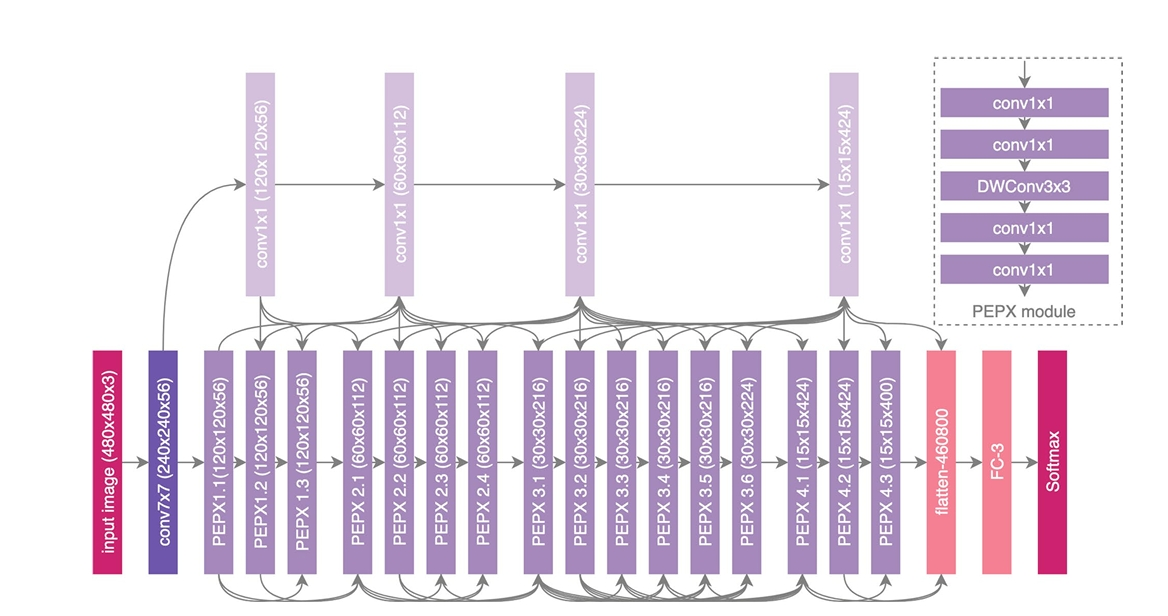

Figure 5. COVID-Net architecture from: Wang, L., Lin, Z. Q., & Wong, A. (2020). COVID-Net: a tailored deep convolutional neural network design for detection of COVID-19 cases from chest X-ray images. Scientific Reports, 10(1), 19549. https://doi.org/10.1038/s41598-020-76550-z

In [ ]:
# model architecture:

# The Core Building Block: PEPX Module
def pepx_module(input_tensor, project_filters, expand_filters, out_filters):

    # 1. First-stage Projection (Compress)
    x = Conv2D(project_filters, (1, 1), padding = 'same')(input_tensor)
    x = BatchNormalization()(x)
    x = Activation('relu')(x)
    
    # 2. Expansion (Expand)
    x = Conv2D(expand_filters, (1, 1), padding = 'same')(x)
    x = BatchNormalization()(x)
    x = Activation('relu')(x)
    
    # 3. Depth-wise Representation (Learn Textures)
    x = DepthwiseConv2D((3, 3), padding = 'same')(x)
    x = BatchNormalization()(x)
    x = Activation('relu')(x)
    
    # 4. Second-stage Projection (Compress)
    x = Conv2D(project_filters, (1, 1), padding = 'same')(x)
    x = BatchNormalization()(x)
    x = Activation('relu')(x)
    
    # 5. Extension (Final output size)
    x = Conv2D(out_filters, (1, 1), padding = 'same')(x)
    x = BatchNormalization()(x)
    x = Activation('relu')(x)
    
    # Skip Connection: We need the input to match the output shape to add them together
    if input_tensor.shape[-1] != out_filters:
        shortcut = Conv2D(out_filters, (1, 1), padding = 'same')(input_tensor)
        shortcut = BatchNormalization()(shortcut)
    else:
        shortcut = input_tensor
        
    # Add the shortcut to the output
    x = Add()([x, shortcut])
    return x

def build_covid_net_binary(input_shape = (480, 480, 3)):
    inputs = Input(shape=input_shape)
    
    x = Conv2D(64, (7, 7), strides = (2, 2), padding = 'same')(inputs)
    x = BatchNormalization()(x)
    x = Activation('relu')(x)
    x = MaxPooling2D(pool_size=(2, 2), strides=(2, 2))(x)
    
    # Stage 1: PEPX Blocks
    x = pepx_module(x, project_filters = 32, expand_filters = 128, out_filters = 256)
    x = pepx_module(x, project_filters = 32, expand_filters = 128, out_filters = 256)
    
    x = MaxPooling2D(pool_size = (2, 2))(x)
    
    # Stage 2: PEPX Blocks (Increasing filters as image shrinks)
    x = pepx_module(x, project_filters = 64, expand_filters = 256, out_filters = 512)
    x = pepx_module(x, project_filters = 64, expand_filters = 256, out_filters = 512)
    x = pepx_module(x, project_filters = 64, expand_filters = 256, out_filters = 512)
    
    x = MaxPooling2D(pool_size = (2, 2))(x)
    
    # Stage 3: PEPX Blocks
    x = pepx_module(x, project_filters = 128, expand_filters = 512, out_filters = 1024)
    x = pepx_module(x, project_filters = 128, expand_filters = 512, out_filters = 1024)
    x = pepx_module(x, project_filters = 128, expand_filters = 512, out_filters = 1024)
    
    # The Custom Binary Head
    x = GlobalAveragePooling2D()(x)
    x = Dropout(0.5)(x)
    
    outputs = Dense(1, activation = 'sigmoid', name = 'pneumonia_binary_output')(x)
    model = Model(inputs = inputs, outputs = outputs, name = 'Custom_COVID_Net')
    return model
    

model = build_covid_net_binary()
model.compile(optimizer = Adam(learning_rate = 1e-4), loss = 'binary_crossentropy', metrics = ['accuracy', tf.keras.metrics.AUC(name = 'auc')])
model.summary()

In [ ]:
# Model training:


# ModelCheckpoint: Saves the model only when it hits a new high score.
# We monitor 'val_auc' (Validation Area Under the Curve) because it is a much better 
# metric for imbalanced medical datasets than raw accuracy.
checkpoint = ModelCheckpoint('/kaggle/working/best_covid_net.h5', monitor = 'val_auc', mode = 'max', save_best_only = True, verbose = 1)

early_stop = EarlyStopping(monitor = 'val_auc', mode = 'max', patience = 6, restore_best_weights = True, verbose = 1)

# ReduceLROnPlateau: The "Fine-Tuner".
# If the model gets stuck (loss stops going down for 3 epochs), it cuts the learning 
# rate by 80% (factor = 0.2). This allows the model to take much smaller, more careful 
# steps to find the optimal solution.
reduce_lr = ReduceLROnPlateau(monitor = 'val_loss', factor = 0.2, patience = 3, min_lr = 1e-6, verbose = 1)

callbacks_list = [checkpoint, early_stop, reduce_lr]

# Handle Class Imbalance (Crucial for RSNA)
# From EDA, we know Healthy patients outnumber Pneumonia patients roughly 3-to-1.
class_weights = {
    0: 1.0,  
    1: 3.0   
}

EPOCHS = 30
print(f"Training for up to {EPOCHS} epochs...")
history = model.fit(train_gen,validation_data = val_gen, epochs = EPOCHS, callbacks = callbacks_list, class_weight = class_weights)
print("\nTraining Complete! Best weights locked in and saved.")

In [ ]:
# loading saved model:

model = load_model('/kaggle/input/models/ahmedihab202301122/covid-net/tensorflow2/default/1/best_covid_net.h5')
print("Model is loaded")

# Performance Measurments

In [ ]:
# Plotting Training History:

auc = history.history['auc']
val_auc = history.history['val_auc']
loss = history.history['loss']
val_loss = history.history['val_loss']
epochs_range = range(1, len(auc) + 1)

plt.figure(figsize = (14, 5))

# Area Under the Curve (AUC)
plt.subplot(1, 2, 1)
plt.plot(epochs_range, auc, label = 'Training AUC', linewidth = 2, color = 'blue')
plt.plot(epochs_range, val_auc, label = 'Validation AUC', linewidth = 2, color = 'orange')
plt.title('Model AUC (Pneumonia Detection)', fontsize = 14, fontweight = 'bold')
plt.xlabel('Epoch', fontsize = 12)
plt.ylabel('AUC Score', fontsize = 12)
plt.legend(loc = 'lower right')
plt.grid(True, linestyle = '--', alpha = 0.7)

# Loss (Binary Crossentropy)
plt.subplot(1, 2, 2)
plt.plot(epochs_range, loss, label = 'Training Loss', linewidth = 2, color = 'blue')
plt.plot(epochs_range, val_loss, label = 'Validation Loss', linewidth = 2, color = 'orange')
plt.title('Model Loss', fontsize = 14, fontweight = 'bold')
plt.xlabel('Epoch', fontsize = 12)
plt.ylabel('Loss', fontsize = 12)
plt.legend(loc = 'upper right')
plt.grid(True, linestyle = '--', alpha = 0.7)

plt.tight_layout()
plt.show()

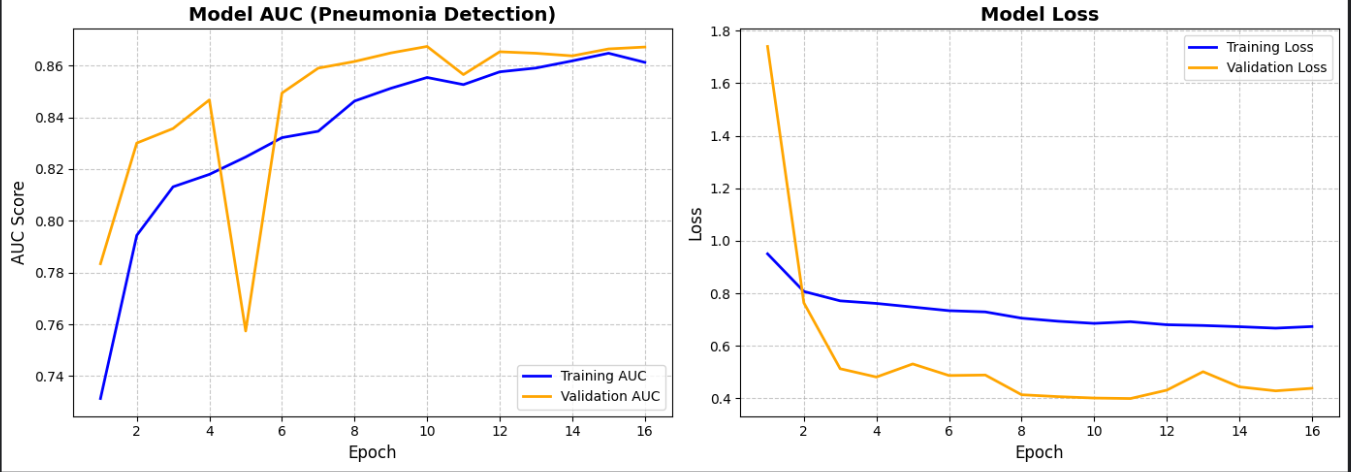

In [ ]:
# Performance Meausrements of the model:

y_pred_prob = model.predict(test_gen, verbose = 1)
y_true = test_gen.df['label'].values
y_pred_binary = (y_pred_prob > 0.5).astype(int)

print("\n" + "="*50)
print("              CLASSIFICATION REPORT")
print("="*50)
print(classification_report(y_true, y_pred_binary, target_names=['Normal (0)', 'Pneumonia (1)']))

plt.figure(figsize=(15, 6))

# Confusion Matrix

plt.subplot(1, 2, 1)
cm = confusion_matrix(y_true, y_pred_binary)
sns.heatmap(cm, annot=True, fmt = 'd', cmap = 'Blues', cbar = False, 
            xticklabels=['Predicted Normal', 'Predicted Pneumonia'],
            yticklabels=['Actual Normal', 'Actual Pneumonia'],
            annot_kws={"size": 14})
plt.title('Confusion Matrix', fontsize = 16, fontweight = 'bold')
plt.xlabel('AI Predictions', fontsize = 12)
plt.ylabel('True Medical Labels', fontsize = 12)

# ROC Curve 

plt.subplot(1, 2, 2)
fpr, tpr, thresholds = roc_curve(y_true, y_pred_prob)
roc_auc = auc(fpr, tpr)

plt.plot(fpr, tpr, color = 'darkorange', lw = 2, label = f'ROC curve (AUC = {roc_auc:.3f})')
plt.plot([0, 1], [0, 1], color = 'navy', lw = 2, linestyle = '--') 
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate', fontsize = 12)
plt.ylabel('True Positive Rate (Sensitivity)', fontsize = 12)
plt.title('Receiver Operating Characteristic (ROC)', fontsize = 16, fontweight = 'bold')
plt.legend(loc="lower right", fontsize = 12)
plt.grid(True, linestyle = '--', alpha = 0.7)

plt.tight_layout()
plt.show()

# XAI Technique - GRAD-Cam

In [ ]:
# Find the Convolutional Layer contains high level spatial features:

last_conv_layer_name = None
for layer in reversed(model.layers):
    if isinstance(layer, tf.keras.layers.Conv2D) or 'conv' in layer.name.lower():
        last_conv_layer_name = layer.name
        break

print(f"Factory hooked into: {last_conv_layer_name}")
grad_model = Model(inputs = [model.inputs],outputs = [model.get_layer(last_conv_layer_name).output, model.output])

In [ ]:
# Compute the Grad-CAM heatmap for a single image tensor function:

def make_gradcam_heatmap(img_tensor):
    with tf.GradientTape() as tape:
        conv_outputs, predictions = grad_model(img_tensor)
        loss = predictions[:, 0]

    grads = tape.gradient(loss, conv_outputs)
    pooled_grads = tf.reduce_mean(grads, axis = (0, 1, 2))
    conv_outputs = conv_outputs[0]
    heatmap = conv_outputs @ pooled_grads[..., tf.newaxis]
    heatmap = tf.squeeze(heatmap)
    
    # ReLU and Normalize
    heatmap = tf.maximum(heatmap, 0) / tf.math.reduce_max(heatmap)
    return heatmap.numpy(), predictions[0][0]

In [ ]:
# Visualization of Grad-CAM function: 

def generate_gradcam_grid(num_images, target_class):
    valid_indices = []
    for i in range(len(y_true)):
        actual = y_true[i]
        predicted = y_pred_binary[i]
        
        if target_class == 'True Positive' and actual == 1 and predicted == 1:
            valid_indices.append(i)
        elif target_class == 'False Positive' and actual == 0 and predicted == 1:
            valid_indices.append(i)
        elif target_class == 'False Negative' and actual == 1 and predicted == 0:
            valid_indices.append(i)

    np.random.shuffle(valid_indices)
    selected_indices = valid_indices[:num_images]
    
    if len(selected_indices) == 0:
        print(f"No patients found matching the criteria: {target_class}")
        return

    fig, axes = plt.subplots(len(selected_indices), 3, figsize=(15, 5 * len(selected_indices)))
    
    # Handle the case where num_images is 1 (axes becomes 1D)
    if len(selected_indices) == 1:
        axes = [axes]

    for row_idx, test_idx in enumerate(selected_indices):
        # Extract Patient Info
        pid = test_gen.df.iloc[test_idx]['patientId']
        img_path = f'/kaggle/working/processed_images/{pid}_full.png'
        
        # Load Images
        raw_img = cv2.imread(img_path, cv2.IMREAD_GRAYSCALE)
        raw_img_display = cv2.cvtColor(raw_img, cv2.COLOR_GRAY2RGB)
        
        # Get mathematical tensor for prediction
        X_batch, _ = test_gen.__getitem__(test_idx // test_gen.batch_size)
        batch_internal_idx = test_idx % test_gen.batch_size
        img_tensor = np.expand_dims(X_batch[batch_internal_idx], axis = 0)
        
        # Generate Heatmap
        heatmap, pred_prob = make_gradcam_heatmap(img_tensor)
        heatmap_resized = cv2.resize(heatmap, (raw_img.shape[1], raw_img.shape[0]))
        heatmap_color = cv2.applyColorMap(np.uint8(255 * heatmap_resized), cv2.COLORMAP_JET)
        
        # Superimposed Image
        superimposed_img = heatmap_color * 0.4 + raw_img_display * 0.6
        superimposed_img = np.clip(superimposed_img, 0, 255).astype(np.uint8)

        ax_orig = axes[row_idx][0]
        ax_heat = axes[row_idx][1]
        ax_super = axes[row_idx][2]
        
        # Original Image + Bounding Boxes
        ax_orig.imshow(raw_img, cmap = 'gray')
        title_orig = f"Patient: {pid[:8]}...\nActual: {target_class.split()[1] if 'False' not in target_class else target_class}"
        
        patient_boxes = labels_df[labels_df['patientId'] == pid]
        if not patient_boxes.empty and patient_boxes['Target'].iloc[0] == 1:
            for _, box_row in patient_boxes.iterrows():
                scale = 480 / 1024 
                x = box_row['x'] * scale
                y = box_row['y'] * scale
                w = box_row['width'] * scale
                h = box_row['height'] * scale
                
                # Draw the Green Doctor Box on Original View
                rect = patches.Rectangle((x, y), w, h, linewidth = 2, edgecolor = 'green', facecolor = 'none')
                ax_orig.add_patch(rect)
                
                # Draw the Green Doctor Box on Superimposed View
                rect_super = patches.Rectangle((x, y), w, h, linewidth = 2, edgecolor = 'green', facecolor = 'none', linestyle = '--')
                ax_super.add_patch(rect_super)
                
            title_orig += "\n(Green Box)"
            
        ax_orig.set_title(title_orig, fontweight = 'bold')
        ax_orig.axis('off')
        
        # 2. Pure Heatmap
        ax_heat.imshow(heatmap_resized, cmap='jet')
        ax_heat.set_title(f"AI Attention Map", fontweight = 'bold')
        ax_heat.axis('off')
        
        # 3. Superimposed View
        ax_super.imshow(superimposed_img)
        ax_super.set_title("Superimposed View\nPrediction", fontweight = 'bold')
        ax_super.axis('off')

    plt.tight_layout()
    plt.show()

In [ ]:
# testing GRAD-Cam on false positives (Model says pneumonia, and the patient actually has pneumonia):


generate_gradcam_grid(num_images = 20, target_class = 'True Positive')

In [ ]:
# testing GRAD-Cam on false positives (Model says pneumonia, but the patient is actually healthy):

generate_gradcam_grid(num_images = 20, target_class = 'False Positive')

In [ ]:
# testing GRAD-Cam on false positives (Model says normal, but the patient actually has pneumonia):

generate_gradcam_grid(num_images = 20, target_class = 'False Negative')